In [41]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

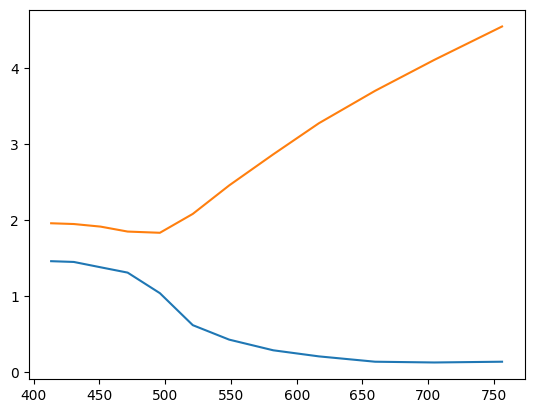

In [45]:
ns = np.loadtxt("temp/analisi/Au_n.txt")
ks = np.loadtxt("temp/analisi/Au_k.txt")
evs = np.loadtxt("temp/analisi/Au_evs.txt")
optical_consts_lambdas = 1240 / evs

min_lambda = 400
max_lambda = 800

lambda_mask = (optical_consts_lambdas >= min_lambda) & (optical_consts_lambdas <= max_lambda)

plt.plot(optical_consts_lambdas[lambda_mask], ns[lambda_mask], label="n")
plt.plot(optical_consts_lambdas[lambda_mask], ks[lambda_mask], label="k")

plt.show()


In [43]:

def sigma_ext(lam, n, k, V_np, n_m):
    return ((18 * np.pi * (n_m)**(3/2)) / (lam)) * V_np * (k / ((n+2*n_m)**2 + k**2))

def absorbance(l, rho, lam, n, k, V_np, n_m):
    sigma = sigma_ext(lam, n, k, V_np, n_m)
    return -np.log10(np.exp(-sigma * rho * l))

def log_likelihood(theta, lam, absorbance_data, n, k, n_m):
    V_np, rho, l, sigma = theta

    prediction = absorbance(l, rho, lam, n, k, V_np, n_m)
    
    gaussian = -0.5 * np.sum(np.log(((absorbance_data - prediction) / sigma) ** 2) + np.log(2 * np.pi * sigma ** 2))
    return gaussian

def log_prior(theta):
    V_np, rho, l, sigma = theta

    V_np_interval = (0, 1e-20)
    rho_interval = (0, 1e20)
    l_interval = (0, 2e-7)
    sigma_interval = (0, 10)

    if V_np_interval[0] < V_np < V_np_interval[1] and rho_interval[0] < rho < rho_interval[1] and l_interval[0] < l < l_interval[1] and sigma_interval[0] < sigma < sigma_interval[1]:
        return 0.0
    return -np.inf

def log_posterior(theta, lam, absorbance_data, n, k, n_m):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, lam, absorbance_data, n, k, n_m)




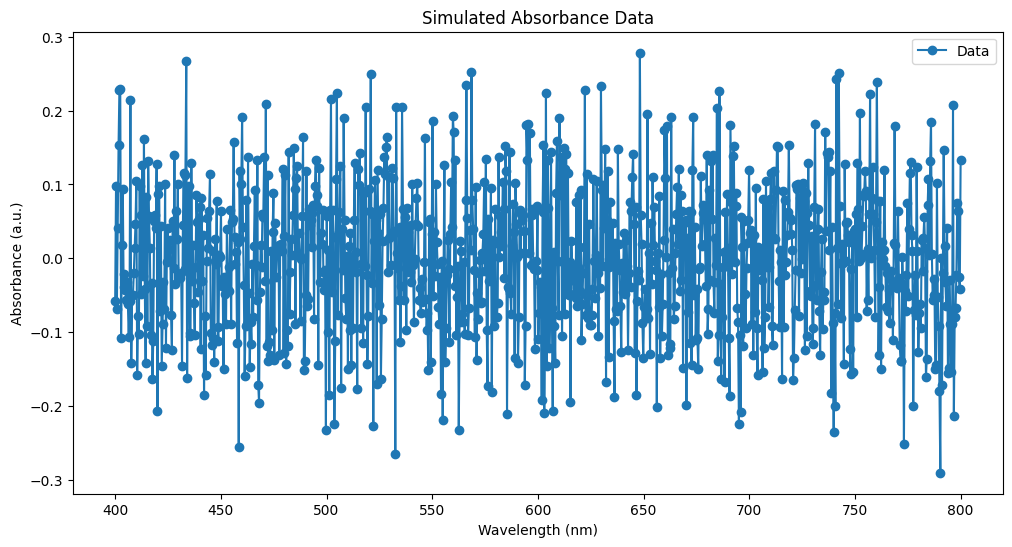

In [48]:
lmbdas = np.linspace(400, 800, 1000) * 1e-9
n_m = 1.33
V_np_true = 4/3 * np.pi * (5e-9)**3
rho_true = 1e18
l_true = 1e-7
sigma_true = 0.1

optical_consts_interp_n = np.interp(lmbdas, optical_consts_lambdas[lambda_mask], ns[lambda_mask]) * 1e-9
optical_consts_interp_k = np.interp(lmbdas, optical_consts_lambdas[lambda_mask], ks[lambda_mask]) * 1e-9
#print("optical_consts_lambdas: ", optical_consts_lambdas[lambda_mask])

absorbance_data = absorbance(l_true, rho_true, lmbdas, optical_consts_interp_n, optical_consts_interp_k, V_np_true, n_m) + np.random.normal(0, sigma_true, size=lmbdas.shape)
plt.figure(figsize=(12, 6))
plt.plot(lmbdas * 1e9, absorbance_data, label="Data", marker='o', linestyle='-')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance (a.u.)")
plt.title("Simulated Absorbance Data")
plt.legend()
plt.show()
